## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from tqdm import tqdm
import sys

# Add parent directory to path to import from src
sys.path.insert(0, '..')

# Import custom modules
from src.model import create_vit_classifier, count_parameters
from src.dataset import BrainTumorDataset, create_dataloaders, get_class_weights
from src.train import Trainer
from src.evaluate import Evaluator, CrossDatasetEvaluator, save_evaluation_results
from src.utils import (
    plot_training_history, plot_confusion_matrix,
    set_seed, get_device, create_experiment_dirs
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("All modules imported successfully!")

All modules imported successfully!


## 2. Configuration

In [2]:
# Set random seed for reproducibility
set_seed(42)

# Get device
device = get_device()

# Hyperparameters
CONFIG = {
    # Data
    'train_metadata': '../Dataset/preprocessed_data/train_metadata.csv',
    'val_metadata': '../Dataset/preprocessed_data/val_metadata.csv',
    'test_metadata': '../Dataset/preprocessed_data/test_metadata.csv',
    'batch_size': 16,
    'num_workers': 4,
    
    # Model
    'image_size': 224,
    'patch_size': 16,
    'num_classes': 2,  # Binary: tumor vs no tumor
    'embed_dim': 768,
    'depth': 12,
    'num_heads': 12,
    'mlp_ratio': 4,
    'dropout': 0.1,
    
    # Training
    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 0.05,
    'patience': 15,
    
    # Paths
    'checkpoint_dir': 'experiments/checkpoints',
    'log_dir': 'experiments/logs',
    'results_dir': 'experiments/results'
}

# Create experiment directories
exp_dirs = create_experiment_dirs('experiments')

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Using GPU: NVIDIA GeForce RTX 4070
Configuration:
  train_metadata: ../Dataset/preprocessed_data/train_metadata.csv
  val_metadata: ../Dataset/preprocessed_data/val_metadata.csv
  test_metadata: ../Dataset/preprocessed_data/test_metadata.csv
  batch_size: 16
  num_workers: 4
  image_size: 224
  patch_size: 16
  num_classes: 2
  embed_dim: 768
  depth: 12
  num_heads: 12
  mlp_ratio: 4
  dropout: 0.1
  num_epochs: 50
  learning_rate: 0.0001
  weight_decay: 0.05
  patience: 15
  checkpoint_dir: experiments/checkpoints
  log_dir: experiments/logs
  results_dir: experiments/results


## 3. Load Data

In [3]:
# Note: Since this notebook is in notebooks/ subdirectory,
# we need to adjust paths or run from the parent directory
# Let's temporarily change to parent directory for data loading
import os
original_dir = os.getcwd()
os.chdir('..')
print(f"Changed directory to: {os.getcwd()}")

# Update CONFIG paths to be relative to project root
CONFIG['train_metadata'] = 'Dataset/preprocessed_data/train_metadata.csv'
CONFIG['val_metadata'] = 'Dataset/preprocessed_data/val_metadata.csv'
CONFIG['test_metadata'] = 'Dataset/preprocessed_data/test_metadata.csv'

# Create dataloaders
train_loader, val_loader, test_loader, class_names = create_dataloaders(
    train_csv=CONFIG['train_metadata'],
    val_csv=CONFIG['val_metadata'],
    test_csv=CONFIG['test_metadata'],
    batch_size=CONFIG['batch_size'],
    num_workers=CONFIG['num_workers'],
    augment_train=True
)

print(f"\nDataset sizes:")
print(f"  Training:   {len(train_loader.dataset):,} samples")
print(f"  Validation: {len(val_loader.dataset):,} samples")
print(f"  Test:       {len(test_loader.dataset):,} samples")

print(f"\nClasses: {class_names}")

# Calculate class weights
class_weights = get_class_weights(CONFIG['train_metadata'])
print(f"\nClass weights: {class_weights}")

Changed directory to: c:\Users\sadman.alif\Desktop\Shawon Thesis

Dataset sizes:
  Training:   5,793 samples
  Validation: 1,242 samples
  Test:       1,242 samples

Classes: ['no tumor', 'tumor']

Class weights: tensor([0.9947, 1.0054])


## 4. Visualize Sample Data

In [ ]:
# Debug: Check dataloader speed
import time
print("Fetching a batch from train_loader...")
start_time = time.time()
images, labels = next(iter(train_loader))
fetch_time = time.time() - start_time
print(f"Batch fetched in {fetch_time:.2f} seconds.")

# Plot sample images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()
    # Denormalize for visualization (approximate)
    img = (img - img.min()) / (img.max() - img.min())
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {class_names[labels[i]]}")
    axes[i].axis('off')

plt.tight_layout()

# Create directory if it doesn't exist
import os
os.makedirs('experiments/results/figures', exist_ok=True)
plt.savefig('experiments/results/figures/sample_data.png', dpi=150, bbox_inches='tight')
plt.show()

Fetching a batch from train_loader...


## 5. Create Model

In [ ]:
# Create Vision Transformer model
model = create_vit_classifier(
    num_classes=CONFIG['num_classes'],
    img_size=CONFIG['image_size'],
    in_channels=3
 )

model = model.to(device)

# Count parameters
num_params = count_parameters(model)
print(f"\nModel: Vision Transformer")
print(f"Total parameters: {num_params:,}")
print(f"Model size: ~{num_params * 4 / (1024**2):.2f} MB")


Model: Vision Transformer
Total parameters: 85,800,194
Model size: ~327.30 MB


## 6. Setup Training

In [ ]:
# Loss function (with class weights)

criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
 )

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CONFIG['num_epochs'],
    eta_min=1e-6
)

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    save_dir=CONFIG['checkpoint_dir'],
    log_dir=CONFIG['log_dir']
    # patience is not a Trainer argument; early stopping is set in train()
 )
print("Training setup complete!")

Training setup complete!


## 7. Train Model

In [ ]:
# Train the model
print("Starting training...\n")

history = trainer.train(num_epochs=CONFIG['num_epochs'])

print("\nTraining complete!")

Starting training...

Starting training for 50 epochs...
Device: cuda
Model parameters: 85,800,194


Epoch 1 [Val]: 100%|██████████| 78/78 [00:01<00:00, 45.15it/s, loss=0.368]



Epoch 1/50 (26.3s)
  Train - Loss: 0.4835, Acc: 0.7899
  Val   - Loss: 0.4821, Acc: 0.7786
  Val   - P: 0.8254, R: 0.7786, F1: 0.7706
  New best model saved! (Val Acc: 0.7786)
----------------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 78/78 [00:01<00:00, 44.85it/s, loss=0.274]



Epoch 2/50 (26.3s)
  Train - Loss: 0.4018, Acc: 0.8305
  Val   - Loss: 0.5100, Acc: 0.7762
  Val   - P: 0.8330, R: 0.7762, F1: 0.7665
----------------------------------------------------------------------


...


Epoch 21/50 (26.5s)
  Train - Loss: 0.2550, Acc: 0.9044
  Val   - Loss: 0.1822, Acc: 0.9348
  Val   - P: 0.9388, R: 0.9348, F1: 0.9347
----------------------------------------------------------------------


Epoch 22 [Val]: 100%|██████████| 78/78 [00:01<00:00, 44.60it/s, loss=0.0175]



Epoch 22/50 (26.5s)
  Train - Loss: 0.2449, Acc: 0.9094
  Val   - Loss: 0.2168, Acc: 0.9171
  Val   - P: 0.9174, R: 0.9171, F1: 0.9170
----------------------------------------------------------------------


Epoch 23 [Val]: 100%|██████████| 78/78 [00:01<00:00, 46.73it/s, loss=0.0154] 


Epoch 23/50 (26.0s)
  Train - Loss: 0.2410, Acc: 0.9120
  Val   - Loss: 0.1721, Acc: 0.9388
  Val   - P: 0.9395, R: 0.9388, F1: 0.9388

Early stopping triggered after 23 epochs

Training completed!
Best validation accuracy: 0.9428

Training complete!


## 8. Plot Training History

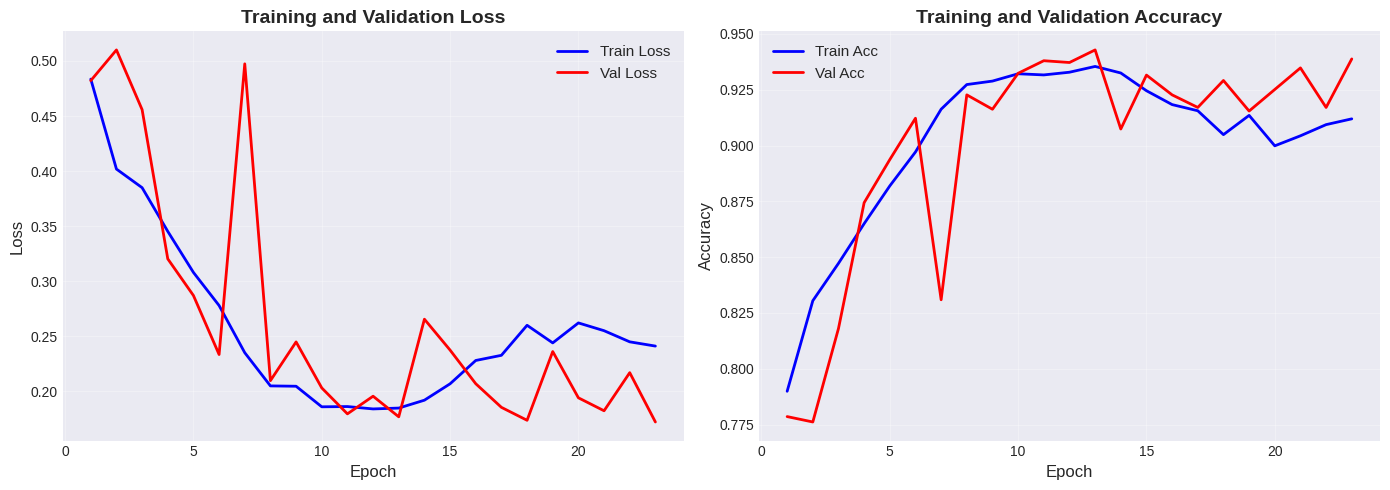


Best Validation Accuracy: 0.9428 at Epoch 13


In [ ]:
# Plot training curves
history_path = Path(CONFIG['checkpoint_dir']) / 'training_history.json'

if history_path.exists():
    plot_training_history(
        history_path,
        save_path='experiments/results/figures/training_history.png'
    )
else:
    print("Training history not found.")

## 9. Evaluate on Test Set

In [ ]:
# Load best model
best_checkpoint_path = Path(CONFIG['checkpoint_dir']) / 'best_model.pth'

if best_checkpoint_path.exists():
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")
    print(f"Best validation accuracy: {checkpoint['best_val_acc']:.4f}")
else:
    print("Best model checkpoint not found. Using current model.")

Loaded best model from epoch 13
Best validation accuracy: 0.9428


In [ ]:
# Create evaluator
evaluator = Evaluator(model, device=device)

# Evaluate on test set
print("Evaluating on test set...\n")
test_metrics = evaluator.evaluate(test_loader, class_names=class_names)

# Print metrics
evaluator.print_metrics(test_metrics, class_names=class_names)

# Save results
save_evaluation_results(
    test_metrics,
    'experiments/results/test_metrics.json',
)

Evaluating on test set...



Evaluating: 100%|██████████| 78/78 [00:01<00:00, 45.92it/s]

EVALUATION METRICS

Overall Metrics:
  Accuracy:           0.9275
  Precision (macro):  0.9309
  Recall (macro):     0.9278
  F1-Score (macro):   0.9274
  ROC-AUC:            0.9812

Per-Class Metrics:

  no tumor:
    Precision: 0.9701
    Recall:    0.8830
    F1-Score:  0.9245

  tumor:
    Precision: 0.8917
    Recall:    0.9725
    F1-Score:  0.9303


Results saved to experiments/results/test_metrics.json


## 10. Confusion Matrix

Getting predictions: 100%|██████████| 78/78 [00:01<00:00, 46.75it/s]


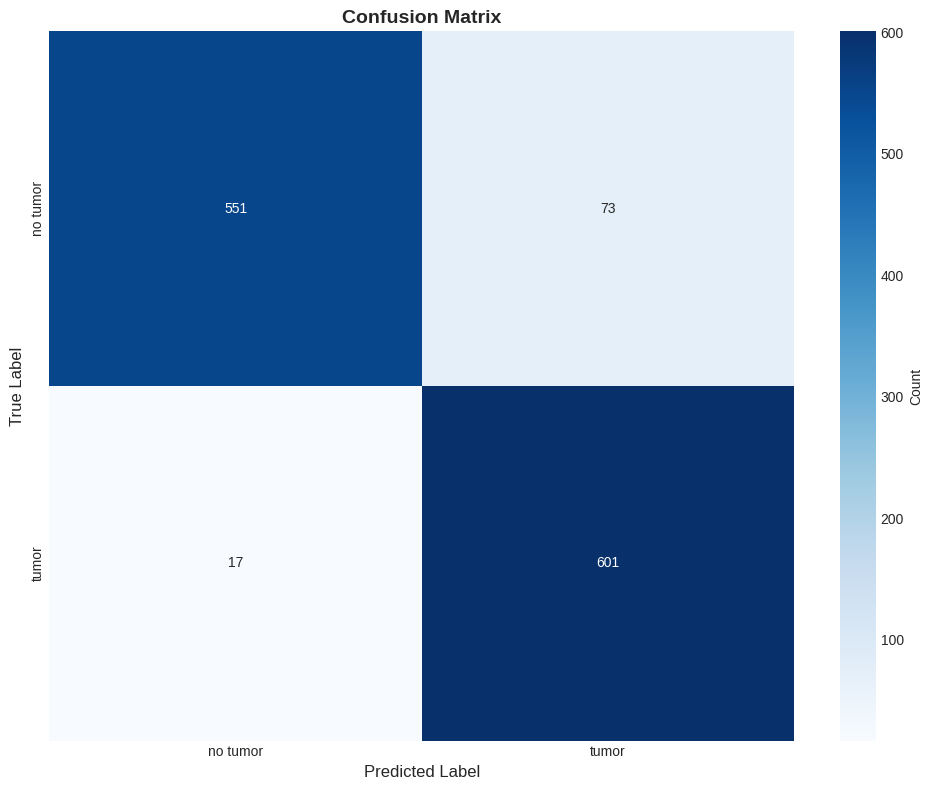


Classification Report:
              precision    recall  f1-score   support

    no tumor     0.9701    0.8830    0.9245       624
       tumor     0.8917    0.9725    0.9303       618

    accuracy                         0.9275      1242
   macro avg     0.9309    0.9278    0.9274      1242
weighted avg     0.9311    0.9275    0.9274      1242



In [ ]:
# Get predictions for confusion matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Getting predictions'):
        if len(batch) == 3:
            images, labels, _ = batch
        else:
            images, labels = batch
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Plot confusion matrix
plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names,
    save_path='experiments/results/figures/confusion_matrix.png'
)

## 11. Cross-Dataset Evaluation (Optional)

In [ ]:
# For cross-dataset evaluation, you need to create separate test loaders
# for each dataset you want to evaluate on

# Example: Evaluate on multiple datasets
# Uncomment and modify as needed

# from dataset import BrainTumorDataset

# # Create dataset-specific test loaders
# dataset1_test = BrainTumorDataset(
#     metadata_csv='path/to/dataset1/test_metadata.csv',
#     apply_augmentation=False
# )
# dataset1_loader = DataLoader(
#     dataset1_test,
#     batch_size=CONFIG['batch_size'],
#     shuffle=False,
#     num_workers=CONFIG['num_workers']
# )

# dataset2_test = BrainTumorDataset(
#     metadata_csv='path/to/dataset2/test_metadata.csv',
#     apply_augmentation=False
# )
# dataset2_loader = DataLoader(
#     dataset2_test,
#     batch_size=CONFIG['batch_size'],
#     shuffle=False,
#     num_workers=CONFIG['num_workers']
# )

# # Evaluate on all datasets
# cross_evaluator = CrossDatasetEvaluator(model, device=device)
# dataloaders_dict = {
#     'Dataset1': dataset1_loader,
#     'Dataset2': dataset2_loader,
#     'Dataset3': test_loader  # Your test set
# }

# results = cross_evaluator.evaluate_all_datasets(
#     dataloaders_dict,
#     class_names=class_names
# )

# # Save cross-dataset results
# save_evaluation_results(
#     results,
#     'experiments/results/cross_dataset_results.json'
# )

print("Cross-dataset evaluation section (modify as needed)")

Cross-dataset evaluation section (modify as needed)


## 12. Visualize Predictions

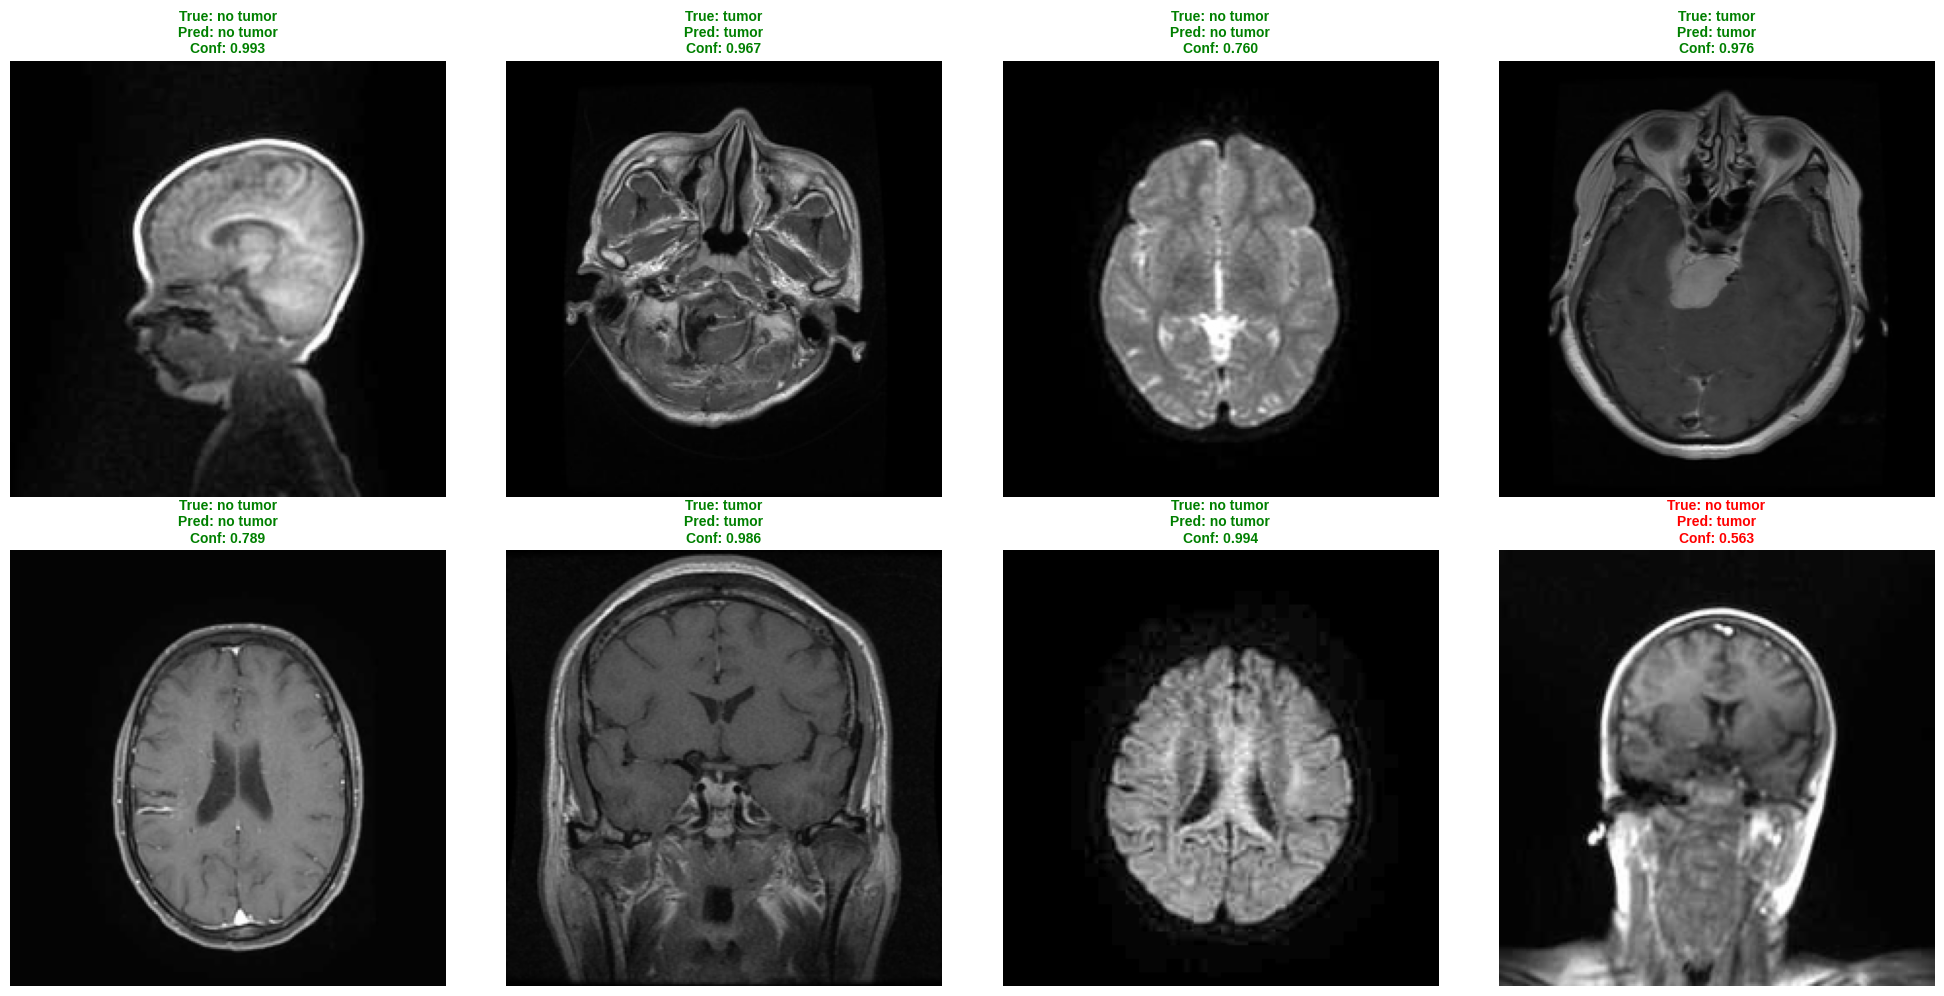

In [ ]:
# Visualize some predictions
model.eval()

# Get a batch of test data
batch = next(iter(test_loader))
if len(batch) == 3:
    test_images, test_labels, _ = batch
else:
    test_images, test_labels = batch
test_images = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images)
    probs = torch.softmax(outputs, dim=1)
    preds = torch.argmax(probs, dim=1)

# Plot predictions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i in range(8):
    img = test_images[i].cpu().permute(1, 2, 0).numpy()
    # Denormalize for visualization
    img = (img - img.min()) / (img.max() - img.min())
    
    true_label = class_names[test_labels[i]]
    pred_label = class_names[preds[i]]
    confidence = probs[i, preds[i]].item()
    
    color = 'green' if preds[i] == test_labels[i] else 'red'
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.3f}",
        color=color,
        fontsize=10,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('experiments/results/figures/predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary

In [ ]:
print("\n" + "="*60)
print("TRAINING SUMMARY")
print("="*60)
print(f"\nModel: Vision Transformer")
print(f"Parameters: {num_params:,}")
print(f"\nDataset:")
print(f"  Training samples:   {len(train_loader.dataset):,}")
print(f"  Validation samples: {len(val_loader.dataset):,}")
print(f"  Test samples:       {len(test_loader.dataset):,}")
print(f"\nTest Performance:")
print(f"  Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"  Precision: {test_metrics['precision_macro']:.4f}")
print(f"  Recall:    {test_metrics['recall_macro']:.4f}")
print(f"  F1-Score:  {test_metrics['f1_macro']:.4f}")
print("\n" + "="*60)
print("\nResults saved to: experiments/results/")
print("Checkpoints saved to: experiments/checkpoints/")
print("TensorBoard logs: experiments/logs/")
print("\nTo view TensorBoard: tensorboard --logdir=experiments/logs")
print("="*60)


TRAINING SUMMARY

Model: Vision Transformer
Parameters: 85,800,194

Dataset:
  Training samples:   5,793
  Validation samples: 1,242
  Test samples:       1,242

Test Performance:
  Accuracy:  0.9275
  Precision: 0.9309
  Recall:    0.9278
  F1-Score:  0.9274


Results saved to: experiments/results/
Checkpoints saved to: experiments/checkpoints/
TensorBoard logs: experiments/logs/

To view TensorBoard: tensorboard --logdir=experiments/logs
